In [2]:
from explainability_global_img import *
#!pip install opencv-python-headless
#from cv2 
import cv2

%load_ext autoreload
%autoreload 2

In [3]:
def blurrings(img, kernel_size = (3,3)):
    return cv2.GaussianBlur(img, kernel_size, 0)

def to_rgb(img):
    if img.ndim == 2: #convert grayscale to RGB
        return np.stack((img,)*3, axis=-1)
    return img

def rescale_img(similarity_map):
    print('mininum: ', np.amin(similarity_map), 'maximum: ', np.amax(similarity_map))
    rescaled_sim_map = similarity_map - np.amin(similarity_map)
    rescaled_sim_map= rescaled_sim_map / np.amax(rescaled_sim_map)
    
    similarity_heatmap = cv2.applyColorMap(np.uint8(255*rescaled_sim_map), cv2.COLORMAP_JET)
    similarity_heatmap = np.float32(similarity_heatmap) / 255
    similarity_heatmap = similarity_heatmap[...,::-1]
        
    return rescaled_sim_map, similarity_heatmap

In [4]:
dataname = 'ETH-80' # 'YaleB' # 'ETH-80', 'UCF'
print("Loading the GRLGQ model!")
fname = "../model/%s/%s_highres_model_d5_ps" % (dataname, dataname) 
# fname = "../model/%s/%s_highres_model_d20_ps" % (dataname, dataname) #UCF

xprotos, yprotos, rel = return_model(fname)
print(xprotos.shape)
dim = xprotos.shape[-1]
D = xprotos.shape[-2]

Loading the GRLGQ model!
train accuracy: 100.0, 	 validation accuracy: 97.5 (100.0)
(8, 6400, 5)


In [6]:

label = 5   #7
set_num = 3  # 7: 6, 9,  0:1

type_mag = 'noabs' #'abs', 'noabs'

imgs, subspace, num2labels = get_data_point(dataname, ith=set_num, cls=label)
print(imgs.shape)
if imgs.shape[0] == 1600:
    imgsize = (40, 40)
elif imgs.shape[0] == 6400:
    imgsize = (80, 80)
elif imgs.shape[0] == 400:
    imgsize=(20, 20)
elif imgs.shape[0] == (38 * 24):
    imgsize=(38, 24)
elif imgs.shape[0] == (4*38*24):
    imgsize = (2*38, 2*24)
elif imgs.shape[0] == (16*38*24):
    imgsize = (4*38, 4*24)
else:
    print(f"Size is not recognizable {imgs.shape[1]}")

(6400, 41)


In [7]:
image_importance_for_distance, pixel_importance_for_distance, protos_rot = get_importance(
    imgs, label, dim, xprotos, yprotos, rel, metric_type='pseudo-chordal'
)

if type_mag=='abs':
    image_importance_for_distance_sorted_ids = np.argsort(np.abs(image_importance_for_distance))
#     pixel_importance_for_distance_sorted_ids = np.argsort(np.abs(pixel_importance_for_distance), axis=0)
else:
    image_importance_for_distance_sorted_ids = np.argsort(image_importance_for_distance)
#     pixel_importance_for_distance_sorted_ids = np.argsort(pixel_importance_for_distance, axis=0)
pixel_importance_for_distance_sorted_ids = np.argsort(pixel_importance_for_distance, axis=0)
# pixel_importance_for_distance_sorted_all_ids = np.argsort(pixel_importance_for_distance, axis=None)



		correct: 	  -0.0865805374229871, 
        normalized:    -0.05926681491176921
plus: 5
minus: 4


mininum:  -0.00010241780130219434 maximum:  8.418982371966919e-05


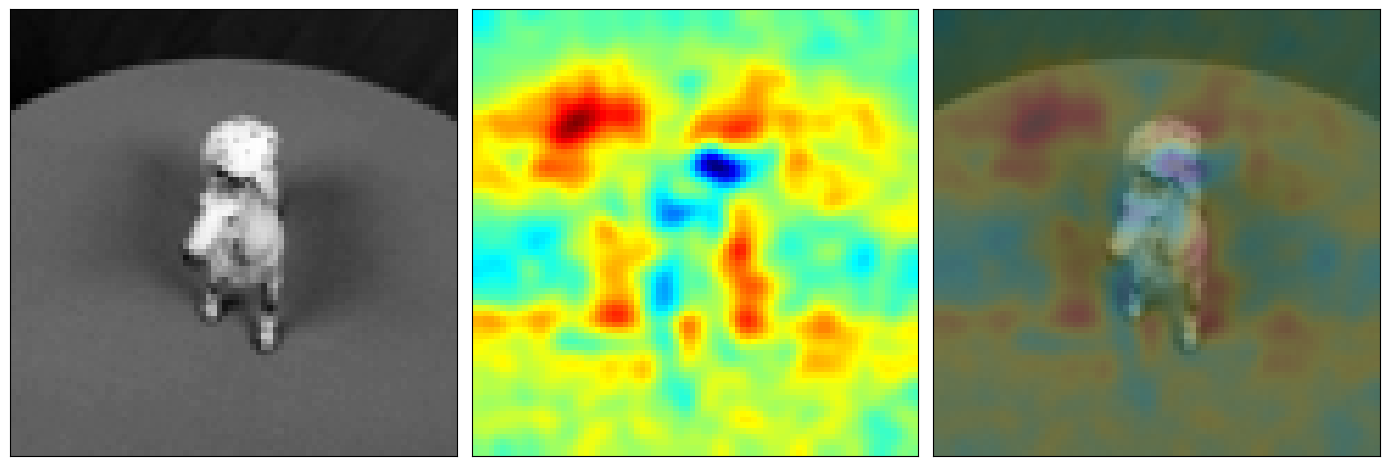

In [8]:
rank = 0
img = np.reshape(imgs[:, image_importance_for_distance_sorted_ids[rank]], imgsize, order='F')

imp = pixel_importance_for_distance[:, image_importance_for_distance_sorted_ids[rank]].reshape(imgsize, order='F')
imp_blur = blurrings(imp, kernel_size=(9,9))

rescaled_imp, heatmap = rescale_img(imp_blur)

overlayed_original_img = 0.5 * to_rgb(img) + 0.2 * heatmap


fig, ax = plt.subplots(1, 3, figsize=(14, 7))

ax[0].imshow(img, cmap='gray')
sc = ax[1].imshow(heatmap)
ax[2].imshow(overlayed_original_img)
ax[0].set_xticks([]), ax[1].set_xticks([]), ax[2].set_xticks([])
ax[0].set_yticks([]), ax[1].set_yticks([]), ax[2].set_yticks([])

plt.tight_layout()


plt.savefig("./image_with_highest_effect.eps")
# plt.imsave(fname=os.path.join(dir,'%s_heatmap_original_image.png'%str(decision_node_idx)), arr=overlayed_original_img, vmin=0.0,vmax=1.0)

In [9]:
# plt.imshow(heatmap)
# masked_similarity_map[similarity_map < np.max(similarity_map)] = 0 

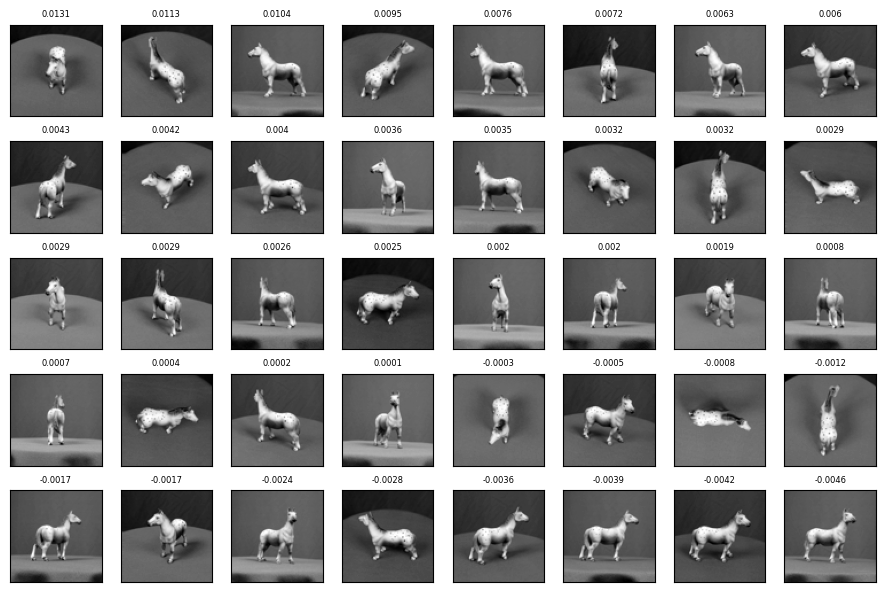

In [10]:
# nrows = imgs.shape[1] // 10 +1 #5
# ncols = 10
nrows = 5
ncols = 8
fig, ax = plt.subplots(nrows, ncols, figsize=(9, 6))
for i in range(40):# range(imgs.shape[1]):
    ax[i//ncols, i%ncols].imshow(np.reshape(imgs[:, image_importance_for_distance_sorted_ids[i]], imgsize, order='F'), cmap='gray')
    ax[i//ncols, i%ncols].set_xticks([])
    ax[i//ncols, i%ncols].set_yticks([])
    ax[i//ncols, i%ncols].set_title(str(
        -round(image_importance_for_distance[image_importance_for_distance_sorted_ids[i]],4)),
        fontsize=6,
    )

plt.tight_layout()
plt.savefig('./sorted_images.eps', dpi=150)
plt.show()


mininum:  -0.00010241780130219434 maximum:  8.418982371966919e-05
mininum:  -4.656821773310592e-05 maximum:  5.4164454349464144e-05
mininum:  -9.104360793611043e-05 maximum:  0.00011378650197479068
mininum:  -7.154672720379086e-05 maximum:  6.781219278268978e-05
mininum:  -8.308174993603467e-05 maximum:  0.00010231786658066919
mininum:  -6.508067107587821e-05 maximum:  0.0001200275471490861
mininum:  -4.6649892451630825e-05 maximum:  6.387519465140046e-05
mininum:  -6.714115655767047e-05 maximum:  5.977135462953209e-05
mininum:  -5.008406868713715e-05 maximum:  9.364864029966809e-05
mininum:  -9.664104659063438e-05 maximum:  9.0758219287049e-05
mininum:  -8.98856516693915e-05 maximum:  0.00011086096452901806
mininum:  -5.885290103069272e-05 maximum:  5.4929428115587606e-05
mininum:  -5.3167161769392364e-05 maximum:  4.3610265045335245e-05
mininum:  -6.632041536506023e-05 maximum:  3.48593993896259e-05
mininum:  -6.58031374862029e-05 maximum:  6.036024037453788e-05
mininum:  -4.67711025

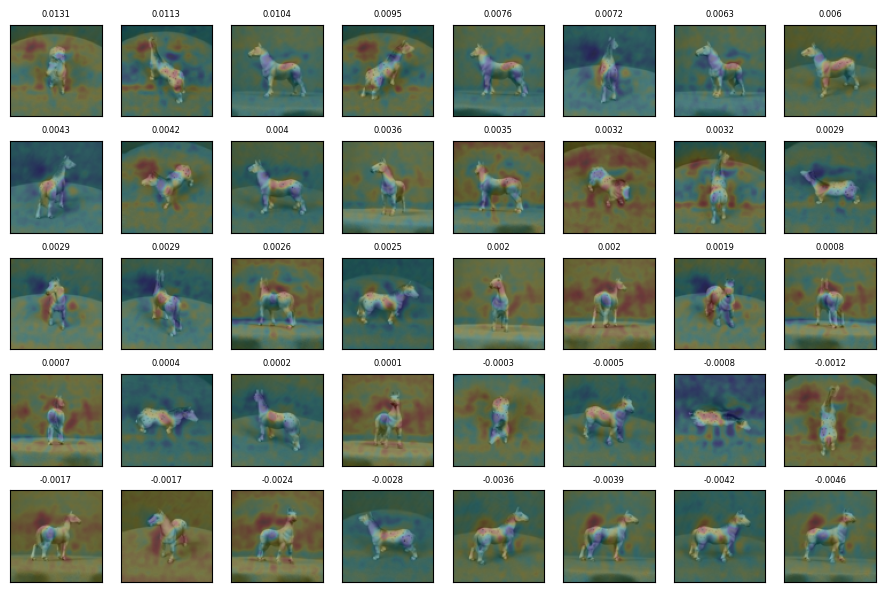

In [11]:
# nrows = imgs.shape[1] // 10 +1 #5
# ncols = 10
nrows = 5
ncols = 8
fig, ax = plt.subplots(nrows, ncols, figsize=(9, 6))
for i in range(40):# range(imgs.shape[1]):
    img = np.reshape(imgs[:, image_importance_for_distance_sorted_ids[i]], imgsize, order='F')

    imp = pixel_importance_for_distance[:, image_importance_for_distance_sorted_ids[i]].reshape(imgsize, order='F')
    imp_blur = blurrings(imp, kernel_size=(9,9))

    rescaled_imp, heatmap = rescale_img(imp_blur)

    overlayed_original_img = 0.5 * to_rgb(img) + 0.2 * heatmap
    
    ax[i//ncols, i%ncols].imshow(overlayed_original_img)
    
#     ax[i//ncols, i%ncols].imshow(np.reshape(imgs[:, image_importance_for_distance_sorted_ids[i]], imgsize, order='F'), cmap='gray')
    ax[i//ncols, i%ncols].set_xticks([])
    ax[i//ncols, i%ncols].set_yticks([])
    ax[i//ncols, i%ncols].set_title(str(
        -round(image_importance_for_distance[image_importance_for_distance_sorted_ids[i]],4)),
        fontsize=6,
    )

plt.tight_layout()
plt.savefig('./sorted_images_heatmap.eps', dpi=150)
plt.show()
